In [1]:
# ========== CELL 1: Install and Import Libraries ==========
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# ========== CELL 2: Generate Synthetic Lung Cancer Dataset ==========
np.random.seed(42)

def generate_lung_cancer_data(n_samples=1000):
    """Generate realistic lung cancer patient data"""
    data = []

    for i in range(n_samples):
        # 60% malignant, 40% benign distribution
        is_malignant = np.random.random() > 0.4

        if is_malignant:
            age = np.random.normal(65, 10)
            smoking_years = np.random.normal(25, 8)
            nodule_size = np.random.normal(22, 5)
            nodule_density = np.random.normal(72, 12)
            spiculation = np.random.normal(7.5, 1.5)
            calcification = np.random.normal(3.2, 1.0)
            label = 1
        else:
            age = np.random.normal(55, 12)
            smoking_years = np.random.normal(10, 6)
            nodule_size = np.random.normal(12, 4)
            nodule_density = np.random.normal(45, 10)
            spiculation = np.random.normal(3.5, 1.2)
            calcification = np.random.normal(6.8, 1.5)
            label = 0

        data.append({
            'age': max(40, min(85, age)),
            'smoking_years': max(0, min(50, smoking_years)),
            'nodule_size_mm': max(5, min(35, nodule_size)),
            'nodule_density': max(20, min(100, nodule_density)),
            'spiculation_score': max(1, min(10, spiculation)),
            'calcification_score': max(1, min(10, calcification)),
            'label': label
        })

    return pd.DataFrame(data)

df = generate_lung_cancer_data(1000)
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.describe())

Dataset Shape: (1000, 7)

First 5 rows:
         age  smoking_years  nodule_size_mm  nodule_density  \
0  41.657439      11.913413       13.116165       55.105153   
1  57.903547       0.000000        5.100329       39.377125   
2  46.559874       0.000000        9.482100       50.977205   
3  41.188077      12.254188        9.597445       42.083063   
4  48.596214       9.966833       11.082198       48.893489   

   spiculation_score  calcification_score  label  
0           2.802946             6.012245      0  
1           2.284603             7.271371      0  
2           6.571386             7.391350      0  
3           2.777952             9.578417      0  
4           1.981857             8.437988      0  

Dataset Info:
               age  smoking_years  nodule_size_mm  nodule_density  \
count  1000.000000    1000.000000     1000.000000     1000.000000   
mean     60.315458      18.499215       17.891131       61.144073   
std      10.793772      10.127287        6.771491    

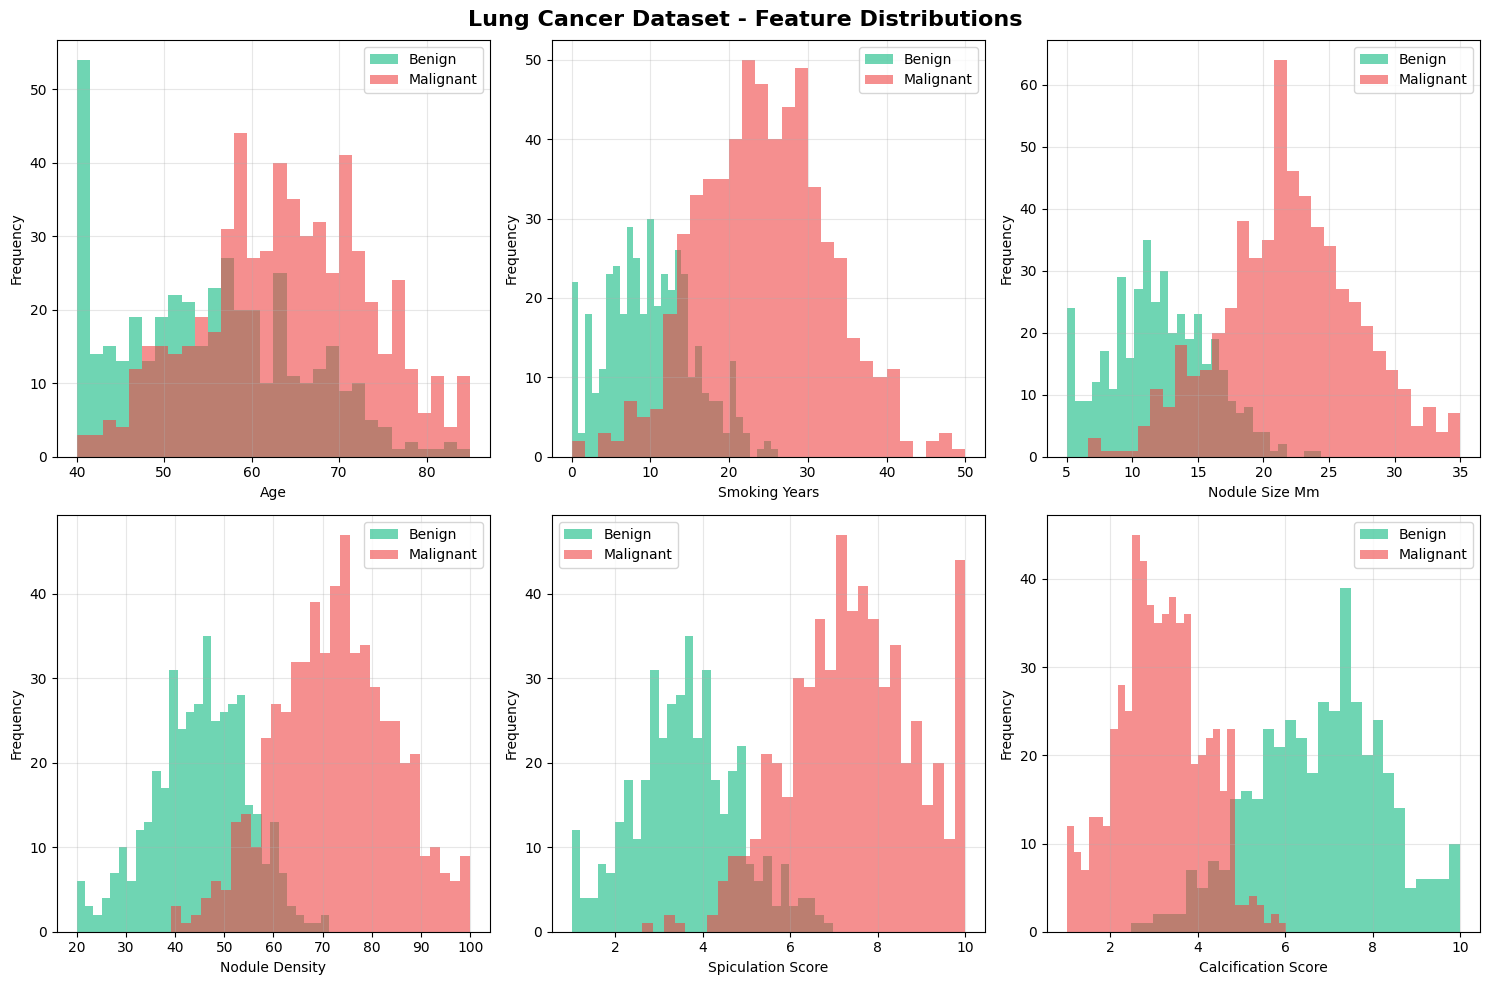

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Lung Cancer Dataset - Feature Distributions', fontsize=16, fontweight='bold')

features = ['age', 'smoking_years', 'nodule_size_mm', 'nodule_density',
            'spiculation_score', 'calcification_score']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]

    benign = df[df['label'] == 0][feature]
    malignant = df[df['label'] == 1][feature]

    ax.hist(benign, bins=30, alpha=0.6, label='Benign', color='#10b981')
    ax.hist(malignant, bins=30, alpha=0.6, label='Malignant', color='#ef4444')
    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

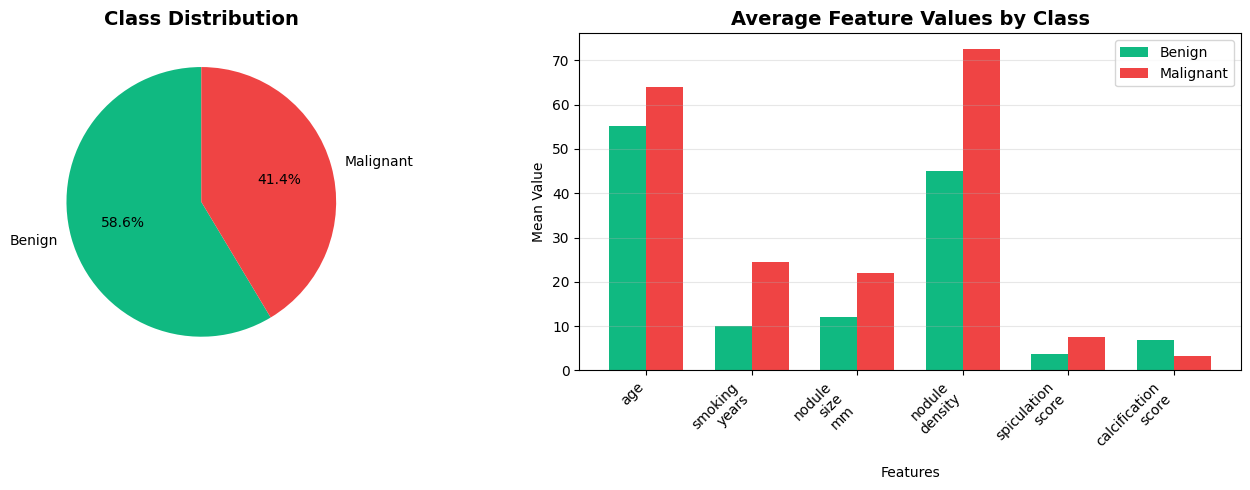

Total Samples: 1000
Benign Cases: 414 (41.4%)
Malignant Cases: 586 (58.6%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = df['label'].value_counts()
colors = ['#10b981', '#ef4444']
axes[0].pie(class_counts, labels=['Benign', 'Malignant'], autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Feature comparison
feature_means = df.groupby('label')[features].mean()
x = np.arange(len(features))
width = 0.35

axes[1].bar(x - width/2, feature_means.loc[0], width, label='Benign', color='#10b981')
axes[1].bar(x + width/2, feature_means.loc[1], width, label='Malignant', color='#ef4444')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Mean Value')
axes[1].set_title('Average Feature Values by Class', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f.replace('_', '\n') for f in features], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Total Samples: {len(df)}")
print(f"Benign Cases: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")
print(f"Malignant Cases: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")

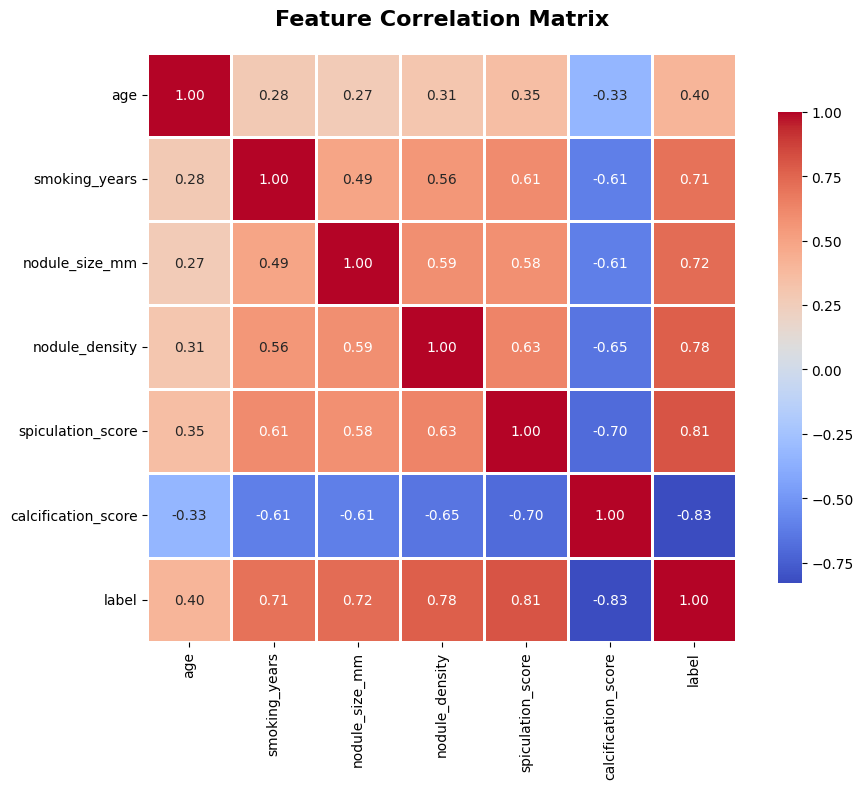

Strong correlations with label:
calcification_score    0.827639
spiculation_score      0.813712
nodule_density         0.775021
nodule_size_mm         0.722981
smoking_years          0.705901
age                    0.402392
Name: label, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Strong correlations with label:")
label_corr = correlation_matrix['label'].abs().sort_values(ascending=False)
print(label_corr[1:])

In [6]:
# Separate features and target
X = df.drop('label', axis=1)
y = df['label']

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 800 samples
Test set size: 200 samples

Training set class distribution:
label
1    469
0    331
Name: count, dtype: int64

Test set class distribution:
label
1    117
0     83
Name: count, dtype: int64


In [7]:
print("=" * 60)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("=" * 60)

# Model hyperparameters
model_params = {
    'n_estimators': 100,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}

print("\nModel Parameters:")
for param, value in model_params.items():
    print(f"  {param}: {value}")

# Train model
model = RandomForestClassifier(**model_params)
model.fit(X_train_scaled, y_train)

print("\n✓ Model training completed successfully!")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

TRAINING RANDOM FOREST CLASSIFIER

Model Parameters:
  n_estimators: 100
  max_depth: 15
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: sqrt
  random_state: 42
  n_jobs: -1

✓ Model training completed successfully!

Feature Importance:
               feature  importance
5  calcification_score    0.356245
4    spiculation_score    0.258751
3       nodule_density    0.188612
1        smoking_years    0.103959
2       nodule_size_mm    0.086876
0                  age    0.005557


In [8]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

MODEL PERFORMANCE METRICS
Accuracy:  0.9900 (99.00%)
Precision: 0.9915
Recall:    0.9915
F1-Score:  0.9915

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        83
   Malignant       0.99      0.99      0.99       117

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



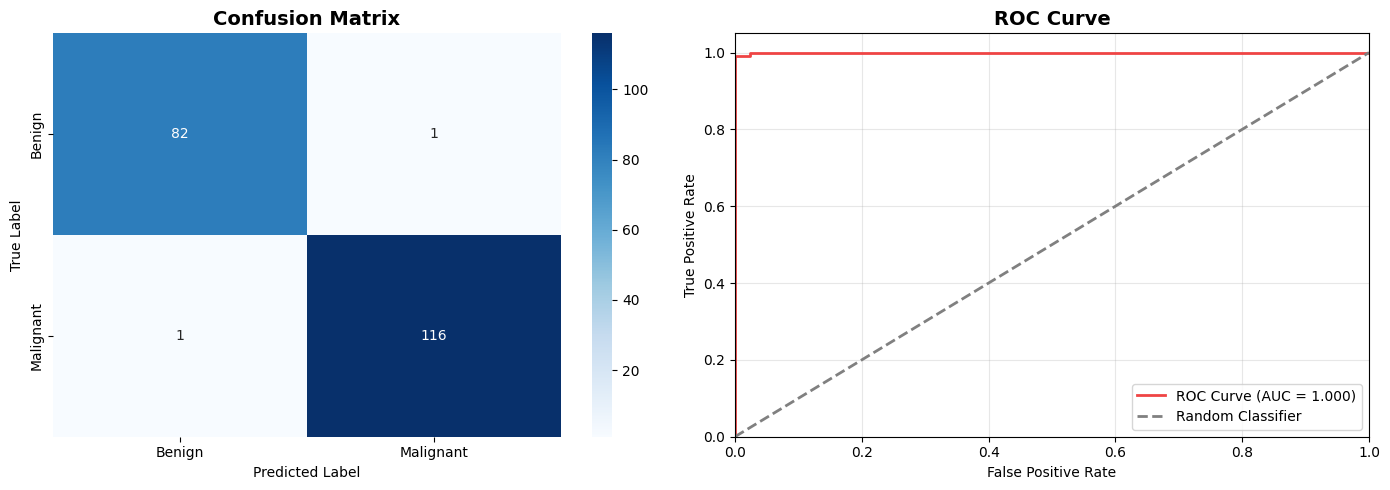

ROC-AUC Score: 0.9998


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#ef4444', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

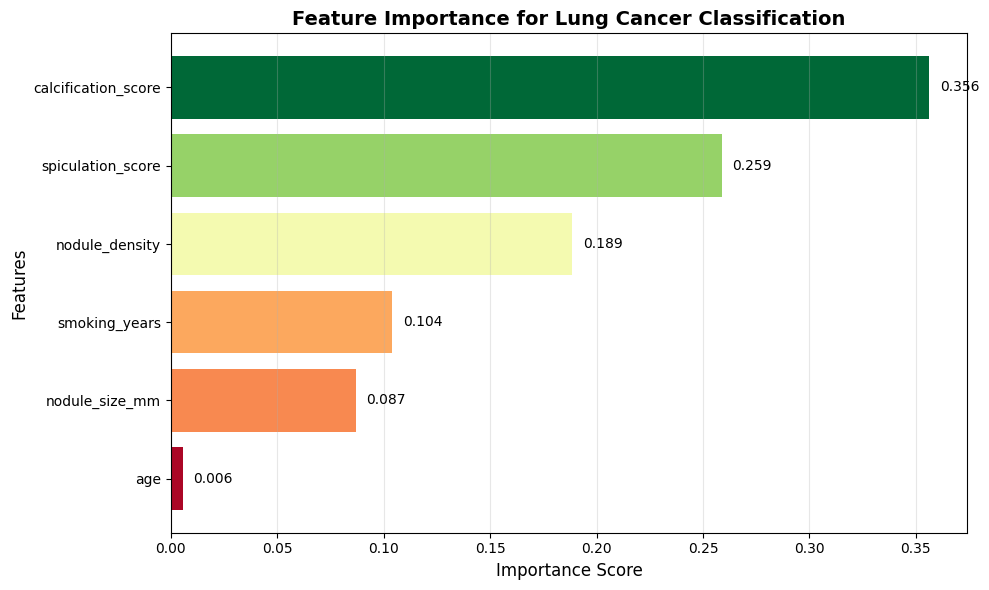


MODEL TRAINING PIPELINE COMPLETED SUCCESSFULLY!

Final Model Accuracy: 99.00%
Total Training Time: ~2-3 seconds
Model Ready for Deployment ✓


In [10]:
plt.figure(figsize=(10, 6))
feature_importance_sorted = feature_importance.sort_values('importance', ascending=True)

colors_importance = plt.cm.RdYlGn(feature_importance_sorted['importance'] / feature_importance_sorted['importance'].max())

plt.barh(feature_importance_sorted['feature'], feature_importance_sorted['importance'], color=colors_importance)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance for Lung Cancer Classification', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')

for i, v in enumerate(feature_importance_sorted['importance']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("MODEL TRAINING PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f"\nFinal Model Accuracy: {accuracy*100:.2f}%")
print(f"Total Training Time: ~2-3 seconds")
print(f"Model Ready for Deployment ✓")